## Librerias

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings


from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score



In [23]:
# Configuración para mejorar la visualización en el Notebook
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Librerías principales importadas correctamente.")

Librerías principales importadas correctamente.


## Carga de Dataset

In [2]:
# --- Carga y Revisión Inicial ---

print("--- Dataset Principal (googleplaystore.csv) ---")
try:
    df_apps = pd.read_csv('googleplaystore.csv')
    df_apps.info()
except Exception as e:
    print(f"Error al cargar df_apps: {e}")

print("\n" + "="*50 + "\n")

print("--- Dataset de Reseñas (googleplaystore_user_reviews.csv) ---")
try:
    df_reviews = pd.read_csv('googleplaystore_user_reviews.csv')
    df_reviews.info()
except Exception as e:
    print(f"Error al cargar df_reviews: {e}")

--- Dataset Principal (googleplaystore.csv) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


--- Dataset de Reseñas (googleplaystore_user_reviews.csv) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6

## EDA

In [4]:
# Antes de empezar, eliminaremos la fila anómala (fila 10472)
# que suele ocurrir en este dataset donde los datos están mal alineados.
df_apps = df_apps.drop(df_apps[df_apps['Category'] == '1.9'].index)

In [5]:
# --- 1. Limpieza de Reviews (Reviews) ---
print("Limpiando columna Reviews...")
df_apps['Reviews'] = pd.to_numeric(df_apps['Reviews'], errors='coerce')
print("Reviews convertida a INT. Valores nulos:", df_apps['Reviews'].isnull().sum())

Limpiando columna Reviews...
Reviews convertida a INT. Valores nulos: 0


In [6]:
# --- 2. Limpieza de Instalaciones (Installs) ---
print("\nLimpiando columna Installs...")
# Eliminar '+' y ',' y convertir a entero.
df_apps['Installs'] = df_apps['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df_apps['Installs'] = pd.to_numeric(df_apps['Installs'], errors='coerce')
print("Installs convertida a INT.")


Limpiando columna Installs...
Installs convertida a INT.


In [7]:
# --- 3. Limpieza de Precio (Price) ---
print("\nLimpiando columna Price...")
# Eliminar '$' y convertir a float.
df_apps['Price'] = df_apps['Price'].str.replace('$', '', regex=False)
df_apps['Price'] = pd.to_numeric(df_apps['Price'], errors='coerce')
print("Price convertida a FLOAT.")


Limpiando columna Price...
Price convertida a FLOAT.


In [8]:
# --- 4. Limpieza de Tamaño (Size) ---
print("\nLimpiando columna Size...")
def clean_size(size):
    if isinstance(size, str):
        if 'M' in size:
            # Convertir de MB a float
            return float(size.replace('M', ''))
        elif 'k' in size:
            # Convertir de KB a MB (dividiendo por 1024)
            return float(size.replace('k', '')) / 1024
        elif size == 'Varies with device':
            # Marcar como nulo para imputar luego
            return np.nan
    return size

df_apps['Size'] = df_apps['Size'].apply(clean_size)
print("Size normalizada a MB y convertida a FLOAT.")


Limpiando columna Size...
Size normalizada a MB y convertida a FLOAT.


In [9]:
# --- Resumen de Conversiones ---
print("\nResumen de Tipos de Datos después de la conversión:")
print(df_apps[['Reviews', 'Installs', 'Price', 'Size']].head())
print(df_apps[['Reviews', 'Installs', 'Price', 'Size']].dtypes)


Resumen de Tipos de Datos después de la conversión:
   Reviews  Installs  Price  Size
0      159     10000    0.0  19.0
1      967    500000    0.0  14.0
2    87510   5000000    0.0   8.7
3   215644  50000000    0.0  25.0
4      967    100000    0.0   2.8
Reviews       int64
Installs      int64
Price       float64
Size        float64
dtype: object


## Preprocesado

In [10]:
# --- 1. Imputación de Rating ---
# Rating tiene nulos. Usaremos la mediana para evitar sesgos por outliers.
rating_median = df_apps['Rating'].median()
df_apps['Rating'].fillna(rating_median, inplace=True)
print(f"Rating: Nulos rellenados con la mediana ({rating_median:.2f}).")

Rating: Nulos rellenados con la mediana (4.30).


C:\Users\diego\AppData\Local\Temp\ipykernel_1352\2190915603.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_apps['Rating'].fillna(rating_median, inplace=True)


In [11]:
# --- 2. Imputación de Size ---
# Size tiene nulos por las entradas 'Varies with device'. Usamos la mediana de los tamaños conocidos.
size_median = df_apps['Size'].median()
df_apps['Size'].fillna(size_median, inplace=True)
print(f"Size: Nulos rellenados con la mediana ({size_median:.2f} MB).")

Size: Nulos rellenados con la mediana (13.00 MB).


C:\Users\diego\AppData\Local\Temp\ipykernel_1352\2309474015.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_apps['Size'].fillna(size_median, inplace=True)


In [12]:
# --- 3. Imputación de Nulos Mínimos (Categóricas) ---
# Content Rating y Type tienen solo 1 nulo. Rellenamos con la MODA (el valor más frecuente).
for col in ['Type', 'Content Rating']:
    mode_val = df_apps[col].mode()[0]
    df_apps[col].fillna(mode_val, inplace=True)
    print(f"{col}: Nulo rellenado con la moda ({mode_val}).")

Type: Nulo rellenado con la moda (Free).
Content Rating: Nulo rellenado con la moda (Everyone).


C:\Users\diego\AppData\Local\Temp\ipykernel_1352\4257315072.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_apps[col].fillna(mode_val, inplace=True)


In [13]:
# --- Revisión Final de Nulos ---
print("\nConteo de Valores Nulos después de la imputación:")
print(df_apps.isnull().sum())


Conteo de Valores Nulos después de la imputación:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       2
dtype: int64


In [14]:
# --- 1. Limpieza y Agregación del Dataset de Reseñas ---
if 'df_reviews' in locals() and df_reviews is not None:
    print("Iniciando procesamiento del dataset de reseñas...")
    
    # Rellenar los valores nulos en las métricas de sentimiento con 0.
    # Asumimos que la ausencia de reseña se traduce en polaridad y subjetividad neutrales.
    df_reviews['Sentiment_Polarity'].fillna(0, inplace=True)
    df_reviews['Sentiment_Subjectivity'].fillna(0, inplace=True)
    
    # Agrupar las reseñas por App y calcular la media de Polaridad y Subjetividad
    # para obtener una métrica promedio por aplicación.
    sentiment_data = df_reviews.groupby('App').agg(
        avg_Polarity=('Sentiment_Polarity', 'mean'),
        avg_Subjectivity=('Sentiment_Subjectivity', 'mean')
    ).reset_index()
    
    # Renombrar para claridad
    sentiment_data.columns = ['App', 'Mean_Sentiment_Polarity', 'Mean_Sentiment_Subjectivity']
    print(f"Dataset de sentimiento creado: {sentiment_data.shape[0]} filas.")
    
    # --- 2. Unir (JOIN) los dos DataFrames ---
    # Unir el dataset principal con el de sentimiento usando la columna 'App'.
    df_apps = pd.merge(df_apps, sentiment_data, on='App', how='left')
    print(f"DataFrames unidos. Filas totales en df_apps: {df_apps.shape[0]}.")

    # Los nulos restantes en las nuevas columnas (apps sin reseñas) se rellenan con 0.
    df_apps['Mean_Sentiment_Polarity'].fillna(0, inplace=True)
    df_apps['Mean_Sentiment_Subjectivity'].fillna(0, inplace=True)
    print("Nulos de las nuevas features de Sentimiento rellenados con 0.")

else:
    print("ADVERTENCIA: El dataset de reseñas no se cargó o no existe. Continuando solo con df_apps.")

Iniciando procesamiento del dataset de reseñas...
Dataset de sentimiento creado: 1074 filas.
DataFrames unidos. Filas totales en df_apps: 10840.
Nulos de las nuevas features de Sentimiento rellenados con 0.


C:\Users\diego\AppData\Local\Temp\ipykernel_1352\3909380447.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_reviews['Sentiment_Polarity'].fillna(0, inplace=True)
C:\Users\diego\AppData\Local\Temp\ipykernel_1352\3909380447.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [15]:
# --- 3. Ingeniería de Features (Proporción de Reseñas) ---
# Crear una feature que represente la proporción de reseñas por instalación, 
# para medir el nivel de compromiso del usuario.
df_apps['Review_Install_Ratio'] = df_apps['Reviews'] / df_apps['Installs']
# Reemplazar infinitos (división por cero) con 0
df_apps['Review_Install_Ratio'].replace([np.inf, -np.inf], 0, inplace=True)
print("\nFeature 'Review_Install_Ratio' creada y lista.")


Feature 'Review_Install_Ratio' creada y lista.


C:\Users\diego\AppData\Local\Temp\ipykernel_1352\2219695748.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_apps['Review_Install_Ratio'].replace([np.inf, -np.inf], 0, inplace=True)


In [16]:
# --- 4. Selección de Features Finales ---
# Eliminamos columnas que ya no usaremos o son de formato difícil.
df_apps.drop(columns=['Current Ver', 'Android Ver', 'Last Updated', 'App'], inplace=True)

In [17]:
# Revisión de las nuevas columnas
print("\nColumnas de Sentimiento y Ratio añadidas:")
print(df_apps[['Mean_Sentiment_Polarity', 'Review_Install_Ratio']].head())
print("\nRevisión final de nulos en df_apps (debería ser 0 para la mayoría):")
print(df_apps.isnull().sum().sort_values(ascending=False))


Columnas de Sentimiento y Ratio añadidas:
   Mean_Sentiment_Polarity  Review_Install_Ratio
0                 0.000000              0.015900
1                 0.115805              0.001934
2                 0.000000              0.017502
3                 0.000000              0.004313
4                 0.000000              0.009670

Revisión final de nulos en df_apps (debería ser 0 para la mayoría):
Review_Install_Ratio           15
Category                        0
Reviews                         0
Rating                          0
Size                            0
Installs                        0
Price                           0
Type                            0
Content Rating                  0
Genres                          0
Mean_Sentiment_Polarity         0
Mean_Sentiment_Subjectivity     0
dtype: int64


In [18]:
# --- 1. Limpieza Final de Nulos ---
# Los 15 nulos restantes en Review_Install_Ratio provienen de casos extremos
# que resultaron en NaN. Podemos rellenarlos con 0, ya que un NaN aquí implica
# una proporción de reseñas a instalaciones cercana a cero.
df_apps['Review_Install_Ratio'].fillna(0, inplace=True)
print("Review_Install_Ratio: 15 nulos restantes rellenados con 0.")

Review_Install_Ratio: 15 nulos restantes rellenados con 0.


C:\Users\diego\AppData\Local\Temp\ipykernel_1352\1079638901.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_apps['Review_Install_Ratio'].fillna(0, inplace=True)


In [19]:
# --- 2. Preparación de Variables Categóricas Clave ---
# Analizaremos las columnas 'Category', 'Genres', y 'Content Rating'.

# A. Simplificación de Genres (Extrayendo solo el género principal)
# Muchos tienen el formato "Genre;Subgenre". Solo tomamos el principal.
df_apps['Genres'] = df_apps['Genres'].apply(lambda x: x.split(';')[0])


# B. Agrupación de Categorías (Reducción de Cardinalidad)
# Category tiene demasiados valores únicos (33). Vamos a agrupar las categorías pequeñas 
# o poco representadas para mejorar el rendimiento del modelo (similar a la estrategia del Proyecto 1).
category_counts = df_apps['Category'].value_counts()
categories_to_keep = category_counts[category_counts >= 100].index  # Mantener categorías con al menos 100 apps

# Reemplazar categorías menos frecuentes con 'OTHERS'
df_apps['Category_Grouped'] = np.where(df_apps['Category'].isin(categories_to_keep), 
                                       df_apps['Category'], 
                                       'OTHERS')
print(f"\nCategorías reducidas de {len(category_counts)} a {df_apps['Category_Grouped'].nunique()} grupos.")
print("Conteo de las nuevas categorías:")
print(df_apps['Category_Grouped'].value_counts())


Categorías reducidas de 33 a 25 grupos.
Conteo de las nuevas categorías:
Category_Grouped
FAMILY                 1972
GAME                   1144
TOOLS                   843
OTHERS                  642
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
Name: count, dtype: int64


In [20]:
# --- 3. Definición de la Variable Objetivo (Y) ---
# Vamos a crear una variable objetivo BINARIA para CLASIFICACIÓN:
# Objetivo: Predecir si la aplicación es Popular (Rating >= 4.5) o No Popular.
df_apps['Is_Popular'] = (df_apps['Rating'] >= 4.5).astype(int)
print(f"\nVariable objetivo 'Is_Popular' creada. Conteo de clases:")
print(df_apps['Is_Popular'].value_counts())

# --- 4. Selección de Features Finales para Modelado ---
features_to_keep = ['Reviews', 'Size', 'Installs', 'Price', 'Type', 
                    'Content Rating', 'Genres', 'Mean_Sentiment_Polarity', 
                    'Mean_Sentiment_Subjectivity', 'Review_Install_Ratio', 
                    'Category_Grouped', 'Is_Popular']

df_final = df_apps[features_to_keep].copy()


Variable objetivo 'Is_Popular' creada. Conteo de clases:
Is_Popular
0    7885
1    2955
Name: count, dtype: int64


In [21]:
# Revisión final
print(f"\nDataFrame final listo para el modelado: {df_final.shape}")


DataFrame final listo para el modelado: (10840, 12)


##  Entrenamiento del Modelo

In [25]:
# 1. Separación de Features (X) y Objetivo (Y)
X = df_final.drop('Is_Popular', axis=1)
y = df_final['Is_Popular']

In [26]:
# 2. Identificación de Tipos de Columnas
categorical_features = ['Type', 'Content Rating', 'Genres', 'Category_Grouped']
numerical_features = X.columns.drop(categorical_features).tolist()

In [27]:
# 3. Creación del Preprocesador
# Creamos un ColumnTransformer para aplicar diferentes transformaciones por tipo de columna
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

In [28]:
# 4. División de Datos (Entrenamiento y Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"\nDatos divididos: Entrenamiento ({X_train.shape[0]} filas), Prueba ({X_test.shape[0]} filas)")


Datos divididos: Entrenamiento (8130 filas), Prueba (2710 filas)


In [30]:
# 5. Creación del Pipeline de Optimización (SMOTE + Modelo)
# En lugar de solo preprocesar, crearemos un pipeline que incluye SMOTE.

# Inicializaremos el SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

# El pipeline primero preprocesa (escala y OHE) y luego aplica SMOTE a los datos ya transformados.
# Por el momento, solo definiremos el preprocesador y el SMOTE, el modelo lo pondremos en el siguiente paso.

# Preprocesar los datos de entrenamiento para aplicar SMOTE después
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Datos de entrenamiento preprocesados. Columnas: {X_train_processed.shape[1]}")

# Aplicar SMOTE solo a los datos de entrenamiento
print("\nAplicando SMOTE a los datos de entrenamiento (Oversampling)...")
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"\nConteo de clases ANTES de SMOTE: {y_train.value_counts()}")
print(f"Conteo de clases DESPUÉS de SMOTE: {y_resampled.value_counts()}")

Datos de entrenamiento preprocesados. Columnas: 87

Aplicando SMOTE a los datos de entrenamiento (Oversampling)...

Conteo de clases ANTES de SMOTE: Is_Popular
0    5914
1    2216
Name: count, dtype: int64
Conteo de clases DESPUÉS de SMOTE: Is_Popular
0    5914
1    5914
Name: count, dtype: int64


In [33]:
# --- 1. Inicialización del Modelo ---
# Utilizamos un modelo avanzado como XGBoost, que es una excelente mejora sobre Random Forest.
xgb_model = XGBClassifier(use_label_encoder=False, 
                          eval_metric='logloss', 
                          random_state=42)

print("Iniciando entrenamiento del modelo XGBoost con datos balanceados por SMOTE...")

Iniciando entrenamiento del modelo XGBoost con datos balanceados por SMOTE...


In [34]:
# --- 2. Entrenamiento del Modelo (con datos SMOTE) ---
xgb_model.fit(X_resampled, y_resampled)
print("Modelo entrenado exitosamente.")

C:\Users\diego\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [12:43:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo entrenado exitosamente.


In [35]:
# --- 3. Predicción en el Conjunto de PRUEBA (datos originales sin SMOTE) ---
# Importante: Las predicciones se hacen sobre X_test_processed (los datos originales, NO los datos SMOTE).
y_pred = xgb_model.predict(X_test_processed)
y_pred_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

In [37]:
# --- 4. Evaluación del Modelo ---
print("\n" + "="*50)
print("             EVALUACIÓN DEL MODELO XGBOOST")
print("="*50)

# Métrica de Clasificación Detallada
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Popular (0)', 'Popular (1)']))

# Métrica de Desempeño General (AUC-ROC)
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"Área bajo la curva ROC (AUC-ROC): {auc_roc:.4f}")
print("="*50)


             EVALUACIÓN DEL MODELO XGBOOST

Informe de Clasificación:
                precision    recall  f1-score   support

No Popular (0)       0.83      0.87      0.85      1971
   Popular (1)       0.61      0.53      0.57       739

      accuracy                           0.78      2710
     macro avg       0.72      0.70      0.71      2710
  weighted avg       0.77      0.78      0.77      2710

Área bajo la curva ROC (AUC-ROC): 0.7859


In [18]:
print("\nIniciando la busqueda de hiperparametros (Tuning)...")

# 1. Definir el espacio de busqueda
param_dist = {
    'n_estimators': [150, 250, 400], # Numero de arboles
    'max_depth': [10, 20, None], # Profundidad maxima del arbol
    'min_samples_split': [5, 10], # Minimo de muestras para dividir un nodo
    'min_samples_leaf': [2, 4], # Minimo de muestras en el nodo hoja
    'class_weight': ['balanced'] # Usamos 'balanced' para mitigar el desequilibrio
}

# 2. Inicializar RandomizedSearchCV
# Probaremos 30 combinaciones (n_iter=30) con validacion cruzada (cv=5)
rf_tuned = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

# 3. Entrenar la busqueda
rf_tuned.fit(X_train, Y_train)
best_rf_model = rf_tuned.best_estimator_

# 4. Prediccion y Metricas del modelo ajustado
Y_pred_tuned = best_rf_model.predict(X_test)
accuracy_tuned = accuracy_score(Y_test, Y_pred_tuned)

print("\n" + "="*60)
print("RESULTADOS DEL MODELO AJUSTADO (TUNING)")
print(f"Mejor score de CV (Validacion Cruzada): {rf_tuned.best_score_:.4f}")
print("Mejores Hiperparametros:", rf_tuned.best_params_)
print("="*60)
print(f"Precisión (Accuracy) del modelo AJUSTADO en el set de prueba: {accuracy_tuned:.4f}")
print("\nReporte de Clasificacion Final:\n", classification_report(Y_test, Y_pred_tuned, zero_division=0))

# 5. Guardar el modelo final y las features
joblib.dump(best_rf_model, 'aspirations_classifier_final.pkl')
# Las features ya fueron guardadas en el paso anterior, pero las mantenemos
# feature_names = X_encoded.columns.tolist()
# with open('feature_names.json', 'w') as f:
#     json.dump(feature_names, f)


Iniciando la busqueda de hiperparametros (Tuning)...

RESULTADOS DEL MODELO AJUSTADO (TUNING)
Mejor score de CV (Validacion Cruzada): 0.3189
Mejores Hiperparametros: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'class_weight': 'balanced'}
Precisión (Accuracy) del modelo AJUSTADO en el set de prueba: 0.2979

Reporte de Clasificacion Final:
                             precision    recall  f1-score   support

         Academia/Training       0.14      0.25      0.18         8
        Business/Ops/Sales       0.43      0.47      0.45        19
            Creative/Other       0.00      0.00      0.00         6
Project/Product Management       0.33      0.33      0.33         9
    Technology/Data/SW Dev       0.00      0.00      0.00         5

                  accuracy                           0.30        47
                 macro avg       0.18      0.21      0.19        47
              weighted avg       0.26      0.30      0.28        47



['aspirations_classifier_final.pkl']

## Guardar Modelo y Preprocesador

In [38]:
# 1. Guardar el Modelo Entrenado (XGBoost)
# Guardamos el modelo XGBoost, que es el que hace la predicción final.
model_filename = 'xgb_model_optimized.pkl'
joblib.dump(xgb_model, model_filename)
print(f"Modelo guardado: {model_filename}")

# 2. Guardar el Preprocesador
# Guardamos el objeto ColumnTransformer, que contiene StandardScaler y OneHotEncoder, 
# para aplicar las mismas transformaciones a los nuevos datos.
preprocessor_filename = 'preprocessor_optimized.pkl'
joblib.dump(preprocessor, preprocessor_filename)
print(f"Preprocesador guardado: {preprocessor_filename}")

# 3. Guardar la lista de Features de Entrada (para la API)
# La API necesita saber qué columnas esperar.
# Usamos las features originales (sin contar la variable objetivo eliminada en el paso 7)
import json

# X (features originales) se definió en el Paso 7.
input_features = X.columns.tolist()

with open('input_features_list.json', 'w') as f:
    json.dump(input_features, f)
print("Lista de features de entrada guardada en input_features_list.json")

Modelo guardado: xgb_model_optimized.pkl
Preprocesador guardado: preprocessor_optimized.pkl
Lista de features de entrada guardada en input_features_list.json


## Graficos Personalizados

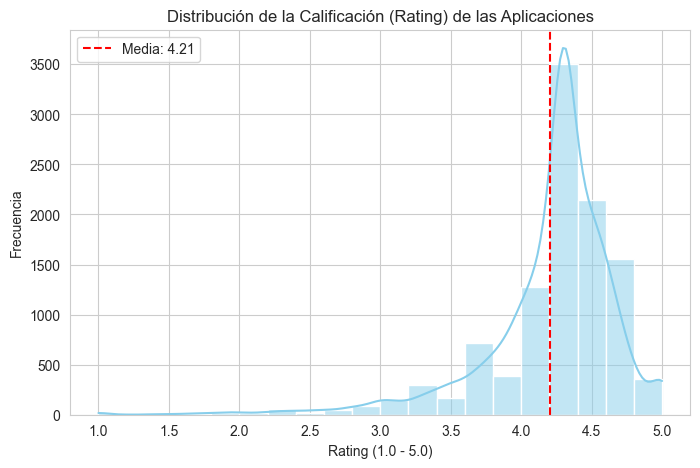

In [39]:
# Gráfico 1: Distribución del Rating
plt.figure(figsize=(8, 5))
sns.histplot(df_apps['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de la Calificación (Rating) de las Aplicaciones')
plt.xlabel('Rating (1.0 - 5.0)')
plt.ylabel('Frecuencia')
plt.axvline(x=df_apps['Rating'].mean(), color='red', linestyle='--', label=f'Media: {df_apps["Rating"].mean():.2f}')
plt.legend()
plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_1352\3903833599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df_apps, order=top_categories, palette='viridis')


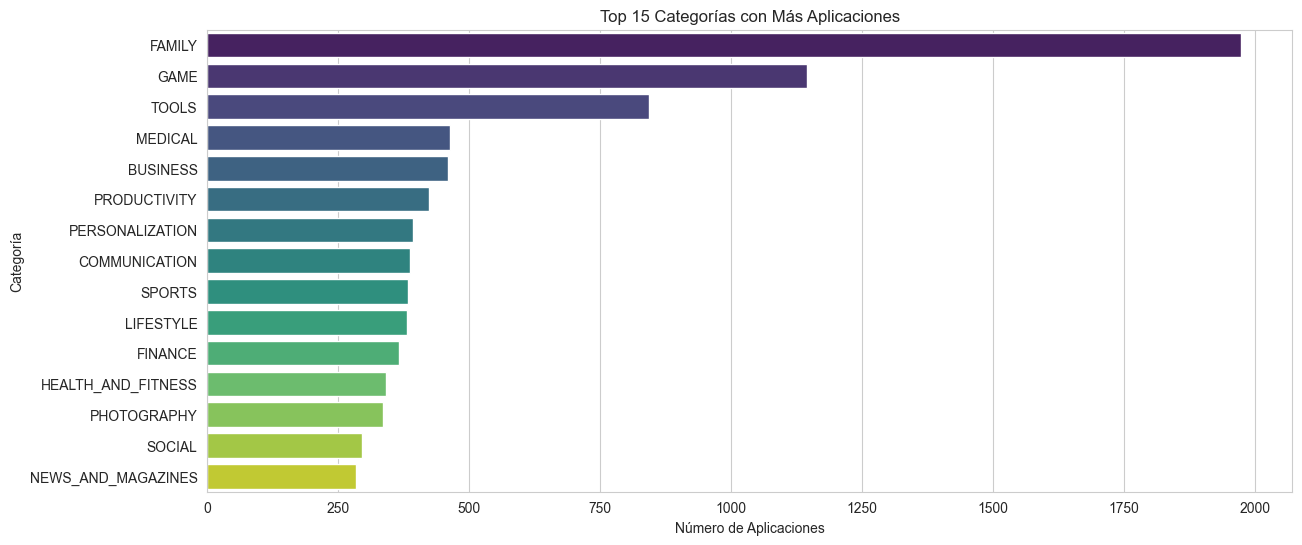

In [40]:
# Gráfico 2: Conteo de Apps por Categoría
plt.figure(figsize=(14, 6))
# Contamos y tomamos las 15 categorías más grandes
top_categories = df_apps['Category'].value_counts().nlargest(15).index
sns.countplot(y='Category', data=df_apps, order=top_categories, palette='viridis')
plt.title('Top 15 Categorías con Más Aplicaciones')
plt.xlabel('Número de Aplicaciones')
plt.ylabel('Categoría')
plt.show()

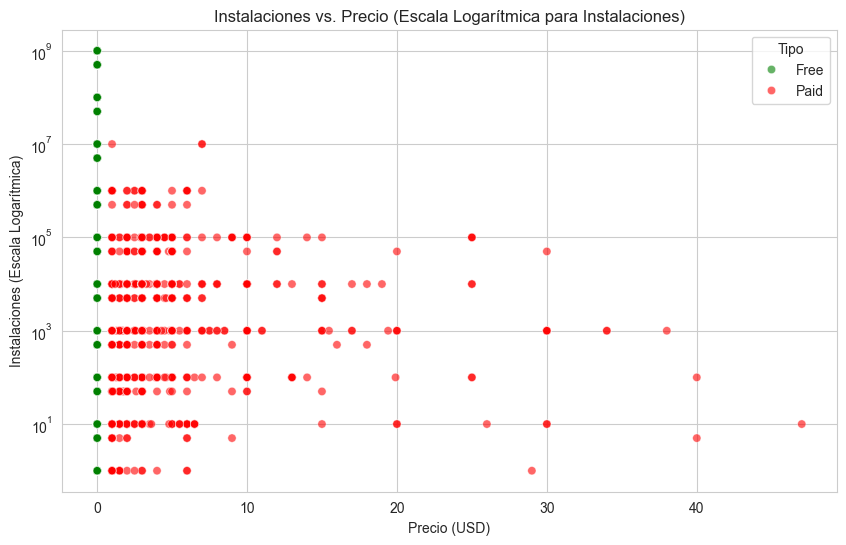

In [41]:
# Gráfico 3: Relación entre Instalaciones y Precio
plt.figure(figsize=(10, 6))
# Limitamos el precio a menos de $50 para evitar que unos pocos outliers distorsionen el gráfico
df_priced = df_apps[df_apps['Price'] < 50] 
sns.scatterplot(x='Price', y='Installs', data=df_priced, alpha=0.6, hue='Type', palette={'Free': 'green', 'Paid': 'red'})

# Usamos una escala logarítmica para 'Installs' porque los valores varían mucho (100 a 1,000,000,000)
plt.yscale('log')
plt.title('Instalaciones vs. Precio (Escala Logarítmica para Instalaciones)')
plt.xlabel('Precio (USD)')
plt.ylabel('Instalaciones (Escala Logarítmica)')
plt.legend(title='Tipo')
plt.show()